# CSE5280 — Robot Arm Simulation

## Objective Summary

Given a 25 × 14 floor plan with 30 agents evacuating toward two exits, deploy a robot arm that:

1. Detects **stuck agents** (near an exit but not moving — trapped by wall geometry)  
2. Uses **Inverse Kinematics** to position its end-effector (EE) tip at floor level next to each agent  
3. Creates a **CHANGE** in the shared gradient field, which deflects the agent's descent direction toward a room door or exit  
4. Works **one agent at a time**, prioritising the most wall-cornered stuck agent, and releases once the agent starts moving

The robot has **no direct control** over agents. Every agent simply follows the negative gradient of a scalar cost function — the robot changes that cost function by being physically present.


##  Gradient-Descent Cost Minimisation

Each agent $i$ maintains a 2D position $\mathbf{p}_i \in \mathbb{R}^2$ and velocity $\mathbf{v}_i \in \mathbb{R}^2$.  
At every time step the agent descends the gradient of a scalar **total cost** $C$:

$$\mathbf{v}_i \leftarrow \mu\,\mathbf{v}_i \;-\; \alpha\,\nabla C(\mathbf{p}_i) \;+\; \boldsymbol{\eta}$$

$$\mathbf{p}_i \leftarrow \mathbf{p}_i + \text{clip}(\mathbf{v}_i,\;-v_{\max},\;v_{\max})$$

| Symbol | Meaning | Value |
|--------|---------|-------|
| $\mu$ | momentum coefficient | 0.30 |
| $\alpha$ | learning rate | 0.055 |
| $\boldsymbol{\eta}$ | Gaussian noise $\sim \mathcal{N}(0, \sigma^2 I)$ | $\sigma = 0.018$ |
| $v_{\max}$ | maximum speed | 0.20 |

### Total Cost Function

$$C(\mathbf{p}) = C_{\text{goal}}(\mathbf{p}) + C_{\text{wall}}(\mathbf{p}) + C_{\text{robot}}^{\text{3D}}(\mathbf{p},\,\mathbf{e}) + C_{\text{rep}}(\mathbf{p})$$

**Goal attraction** — soft-min over both exits:
$$C_{\text{goal}}(\mathbf{p}) = -\tau \ln\!\left(\sum_{k} e^{-\|\mathbf{p}-\mathbf{e}_k\|^2/\tau}\right)$$

**Wall repulsion** — quadratic band around every wall segment:
$$C_{\text{wall}}(\mathbf{p}) = w_{\text{wall}} \sum_j \max(0,\; \delta - d_j(\mathbf{p}))^2$$
where $d_j(\mathbf{p})$ is the distance from $\mathbf{p}$ to wall segment $j$ and $\delta = 0.55$ is the influence band.

**Robot obstacle (3D)** — key innovation:
$$C_{\text{robot}}^{\text{3D}}(\mathbf{p},\,\mathbf{e}) = \begin{cases} w_r\,\bigl(r_r - \|\tilde{\mathbf{p}} - \mathbf{e}\|\bigr)^2 & \text{if } \|\tilde{\mathbf{p}} - \mathbf{e}\| < r_r \\ 0 & \text{otherwise} \end{cases}$$
where $\tilde{\mathbf{p}} = (p_x, p_y, z_{\text{agent}})$ is the agent's **3D** position ($z_{\text{agent}} = 0.22$) and $\mathbf{e} \in \mathbb{R}^3$ is the robot EE tip's full 3D world position.  
Using 3D distance means $C_{\text{robot}}^{\text{3D}} = 0$ when the arm is overhead — **no ghost force**.

**Social repulsion** between nearby agents:
$$C_{\text{rep}}(\mathbf{p}) = w_{\text{rep}} \sum_{j \ne i} \max(0,\; r_{\text{rep}} - \|\mathbf{p} - \mathbf{p}_j\|)^2$$

The gradient $\nabla C$ is computed via **central finite differences** (step $\varepsilon = 10^{-4}$).

### Wall Penetration Prevention

After every position update, an iterative **normal push-out** resolves wall penetration:
for each wall segment that the agent overlaps (distance $< r_{\text{agent}} = 0.42$), project the agent back to the clearance distance along the wall's outward normal. Iterate up to 8 times to handle corners.


## Robot Arm

### STL Parts & Scale

The four physical parts are loaded from 'robot/' (same files as 'robot_arms_inverse_kinematics.ipynb' THE STARTERCODE FILE ):

| Part | File | Height (mm) | Scaled (floor units) |
|------|------|------------|----------------------|
| Base column | 'Base.stl' | 105 | $h_0 = 3.38$ |
| Base rotor | 'BaseRot.stl' | $L_1 = 81$ | 2.61 |
| Humerus | 'Humerus.stl' | $L_2 = 217$ | 6.99 |
| Radius | 'Radius.stl' | $L_3 = 416$ | 13.40 |

Scale factor $s = 23\,/\,(81+217+416) = 23/714 \approx 0.0322$.  
Total reach $= L_1 + L_2 + L_3 = 23$ floor units.

### Homogeneous Transform Chain

The FK follows **exactly** the chain from 'robot_arms_inverse_kinematics.ipynb', using the same helper functions 'RotationMatrix' and 'getLocalFrameMatrix':

$$T_{i-1,i} = \begin{bmatrix} R(\phi_i) & \mathbf{t}_{i-1,i} \\ \mathbf{0}^T & 1 \end{bmatrix}, \qquad T_{0,k} = T_{0,1} \cdot T_{1,2} \cdots T_{k-1,k}$$

| Frame | Rotation | Translation | STL part |
|-------|----------|-------------|----------|
| $T_{00}$ | $R_z(0)$ | $(x_{\rm arm},\, y_{\rm arm},\, 0)$ | Base plate |
| $T_{01}$ | $R_z(\phi_1)$ | $(x_{\rm arm},\, y_{\rm arm},\, h_0)$ | BaseRot |
| $T_{02} = T_{01} T_{12}$ | $R_y(\phi_2)$, $\mathbf{t} = (0,0,L_1+2r)^T$ | Humerus |
| $T_{03} = T_{02} T_{23}$ | $R_y(\phi_3)$, $\mathbf{t} = (0,0,L_2+2r)^T$ | Radius |
| $T_{04} = T_{03} T_{34}$ | $R_y(\phi_4)$, $\mathbf{t} = (-28.4s,\,0,\,L_3+r)^T$ | EE frame |

The **end-effector world position** is the translation column of $T_{04}$:
$$\mathbf{e} = T_{04}[{:}3,\, 3]$$



### Joint Limits

$$\phi_1 \in [-180°,\, 180°] \quad \phi_2 \in [-120°,\, 120°] \quad \phi_3 \in [-180°,\, 180°] \quad \phi_4 \in [-360°,\, 360°]$$


## Robot Guidance Mechanism 

### How Guidance Works (No Separate Algorithm)

The robot has **no direct control** over agents. It works entirely by deforming the cost field:

1. IK positions the EE tip at $\mathbf{e}^{\text{3D}} = (e_x, e_y, 0.22)$ — physically touching the floor next to the agent.
2. $C_{\text{robot}}^{\text{3D}}$ adds a quadratic cost hill centred at $\mathbf{e}^{\text{3D}}$.
3. The gradient $\nabla C_{\text{robot}}^{\text{3D}}$ points **away from the EE tip**, pushing the agent away from $\mathbf{e}$.
4. By placing the EE **0.3 units behind the agent** (opposite the waypoint direction), the push force aligns with the waypoint direction — toward the door or exit.

### Push Direction Analysis

Let $\hat{u} = (\text{waypoint} - \mathbf{p}_i) / \|\cdot\|$ be the unit vector toward the target.  
EE is placed at: $\mathbf{e}^{\text{3D}} = (\mathbf{p}_i - 0.3\,\hat{u},\; 0.22)$

Then $\nabla C_{\text{robot}}^{\text{3D}}$ at $\mathbf{p}_i$ points **away from EE**, i.e. in direction $+\hat{u}$ — toward the waypoint.

| EE offset | Gradient strength | Effect |
|-----------|------------------|--------|
| 1.2 behind | $\|\nabla C\| = 8.1$ (no robot baseline) | Outside influence radius |
| 0.6 behind | $\|\nabla C\| = 14.1$ | Entering influence |
| **0.3 behind** | **$\|\nabla C\| = 21.3$** | **Maximum push — 2.6× stronger** |
| 0.0 (AT agent) | $\|\nabla C\| = 8.1$ (same as no robot) | Symmetric → gradient = 0 |
| 0.3 past agent | Gradient **reverses** | Pushes agent backward ✗ |

**Insight:** placing the EE AT or PAST the agent gives zero or reversed force — the arm must always stay slightly behind.




In [1]:
import subprocess, sys, os
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'vedo', 'scikit-learn'], check=False)

# Download robot STL parts if not already present
if not os.path.exists('robot/'):
    print('Downloading robot STL parts...')
    subprocess.run(
        ['wget', '-q', '-O', 'robot.zip',
         'https://www.dropbox.com/scl/fi/uewvrcempf2wf2jp7bcb8/robot.zip'
         '?rlkey=7uwz1ne94hxyinub8x16y93em&dl=1'],
        check=False)
    subprocess.run(['unzip', '-q', 'robot.zip'], check=False)
    subprocess.run(['rm', '-f', 'robot.zip'], check=False)

print('robot/:', os.listdir('robot/') if os.path.exists('robot/') else 'NOT FOUND')

robot/: ['Humerus.stl', 'BaseRot.stl', 'Radius.stl', 'Base.stl']



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import vedo
from vedo import (
    Plotter, Sphere, Cylinder, Box, Arrow, Disc,
    Text2D, Axes, LinearTransform, Mesh, load
)
from sklearn.cluster import MeanShift

vedo.settings.default_backend = 'vtk'


### Building Layout & Simulation Parameters



In [3]:
# ── Geometry constants ────────────────────────────────────────────────────
WALL_H  = 3.0    # wall height (floor units)
WALL_T  = 0.18   # wall thickness
AGENT_R = 0.42   # agent collision radius for wall push-out
AGENT_Z = 0.22   # agent sphere centre z-height above floor

EXIT_A = np.array([0.0,  7.5])   # west wall gap y∈[6,9]
EXIT_B = np.array([17.5, 14.0])  # north wall gap x∈[16,19]
EXITS  = [EXIT_A, EXIT_B]

# 33 wall segments defining Floor 1 layout
WALL_SEGS = [
    ((0,0),(10,0)),((10,0),(15,0)),((15,0),(20,0)),((20,0),(25,0)),
    ((0,0),(0,5)),((0,5),(0,6)),((0,9),(0,10)),((0,10),(0,14)),
    ((0,14),(10,14)),((10,14),(15,14)),((15,14),(16,14)),
    ((19,14),(20,14)),((20,14),(25,14)),
    ((25,0),(25,3)),((25,3),(25,11)),((25,11),(25,14)),
    ((10,0),(10,5)),((10,10),(10,14)),
    ((15,0),(15,2)),((15,2),(15,5)),((15,10),(15,12)),
    ((20,0),(20,2)),((20,2),(20,3)),((20,12),(20,14)),
    ((2,5),(6,5)),((9,5),(10,5)),((11,5),(14,5)),
    ((2,10),(6,10)),((9,10),(13,10)),
    ((15,2),(16,2)),((18,2),(20,2)),
    ((22,3),(25,3)),((20,11),(25,11)),
]

# ── Simulation parameters ────────────────────────────────────────────────
CFG = dict(
    n_agents=30,        # number of evacuating agents
    lr=0.055,           # gradient descent learning rate α
    max_step=0.20,      # velocity clamp v_max
    momentum=0.30,      # momentum coefficient μ
    noise=0.018,        # Gaussian noise std σ
    exit_tol=1.2,       # distance threshold to declare escape
    seed=42,
    tau=1.0,            # goal softmin temperature τ
    band=0.55,          # wall repulsion band δ
    w_wall=16.0,        # wall repulsion weight w_wall
    r_rep=2.9,          # social repulsion radius
    w_rep=5.0,          # social repulsion weight
    r_robot=0.85,       # EE 3D influence radius r_r
    w_robot=12.0,       # EE obstacle weight w_r
    exit_radius=4.5,    # radius to classify agent as "near exit"
    stuck_speed=0.10,   # speed threshold to classify as "stuck"
    bandwidth=1.5,      # Mean-Shift clustering bandwidth
    horizon=4.0,        # prediction horizon (frames)
)
print(f'{len(WALL_SEGS)} wall segments | 2 exits: A={EXIT_A}, B={EXIT_B}')

33 wall segments | 2 exits: A=[0.  7.5], B=[17.5 14. ]


###  Cost Functions


In [4]:
def dist_seg(xy, A, B):
    """2D distance from point xy to line segment A–B."""
    v = B - A; w = xy - A
    t = np.clip(np.dot(w, v) / (np.dot(v, v) + 1e-12), 0., 1.)
    return float(np.linalg.norm(xy - (A + t * v)))


def resolve_walls(pos, radius=AGENT_R):
    """
    Iterative wall normal push-out (up to 8 passes).
    If agent penetrates any wall segment (dist < radius),
    project it back to the clearance distance along the outward normal.
    Exit gaps are safe because those segments do not appear in WALL_SEGS.
    """
    p = pos.copy()
    for _ in range(8):
        moved = False
        for (x1,y1),(x2,y2) in WALL_SEGS:
            A = np.array([x1,y1], float); B = np.array([x2,y2], float)
            v = B - A; w = p - A
            t = np.clip(np.dot(w,v) / (np.dot(v,v) + 1e-12), 0., 1.)
            closest = A + t*v; diff = p - closest; dist = np.linalg.norm(diff)
            if dist < radius:
                n = diff / (dist + 1e-12)
                p = closest + n * radius
                moved = True
        if not moved:
            break
    p[0] = np.clip(p[0], 0.05, 24.95)
    p[1] = np.clip(p[1], 0.05, 13.95)
    return p


def cost_goal(xy, tau=1.0):
    """Soft-min attraction toward the two exits (Eq. C_goal)."""
    exps = [np.exp(-float(np.dot(xy-e, xy-e)) / tau) for e in EXITS]
    return float(-tau * np.log(max(sum(exps), 1e-300)))


def cost_walls(xy, band=0.55, w_wall=14.0):
    """Quadratic repulsion from all wall segments within band δ."""
    total = 0.
    for (x1,y1),(x2,y2) in WALL_SEGS:
        d = dist_seg(xy, np.array([x1,y1],float), np.array([x2,y2],float))
        if d < band:
            total += w_wall * (band - d)**2
    return total


def cost_robot_3d(xy, ee_3d, r_robot=0.85, w_robot=12.0):
    """
    3D obstacle cost — ZERO when arm is overhead (large z-dist),
    active only when EE tip is at floor level near the agent.
    Agent 3D position: (xy[0], xy[1], AGENT_Z).
    """
    if ee_3d is None:
        return 0.
    d = np.linalg.norm(np.array([xy[0], xy[1], AGENT_Z]) - ee_3d)
    return w_robot * (r_robot - d)**2 if d < r_robot else 0.


def cost_repulsion(xy, others, r_rep=0.9, w_rep=5.0):
    """Quadratic social repulsion from neighbouring agents."""
    total = 0.
    for o in others:
        d = np.linalg.norm(xy - o)
        if 1e-6 < d < r_rep:
            total += w_rep * (r_rep - d)**2
    return total


def total_cost(xy, others, ee_3d, tau, band, w_wall, r_rep, w_rep, r_robot, w_robot):
    """Sum of all cost terms — the scalar field each agent descends."""
    return (cost_goal(xy, tau)
          + cost_walls(xy, band, w_wall)
          + cost_robot_3d(xy, ee_3d, r_robot, w_robot)
          + cost_repulsion(xy, others, r_rep, w_rep))


def gradient_fd(xy, others, ee_3d, eps=1e-4, **kw):
    """2D central-difference gradient of total_cost w.r.t. xy."""
    g = np.zeros(2)
    for k in range(2):
        xp = xy.copy(); xp[k] += eps
        xm = xy.copy(); xm[k] -= eps
        g[k] = (total_cost(xp, others, ee_3d, **kw)
              - total_cost(xm, others, ee_3d, **kw)) / (2 * eps)
    return g


print('Cost functions and wall resolver ready.')

Cost functions and wall resolver ready.


### Robot Arm Parameters

STL dimensions (mm) from the IK notebook scene-setup cell. Scale factor $s = 23/714$ converts mm → floor units.

In [5]:
# STL part dimensions in mm (from robot_arms_inverse_kinematics.ipynb)
_BASE_H_MM = 105.0   # static base column height
_L1_MM     =  81.0   # BaseRot  (L1)
_L2_MM     = 217.0   # Humerus  (L2)
_L3_MM     = 416.0   # Radius   (L3)
_T34_X_MM  = -28.4   # wrist x-offset in local frame
_JRAD_MM   =   0.4   # joint radius (used in FK offsets)

# Scale: total reach = 23 floor units
_S = 23.0 / (_L1_MM + _L2_MM + _L3_MM)   # ≈ 0.03221

BASE_H = _BASE_H_MM * _S   # ≈ 3.38 floor units (≈ wall height)
L1     = _L1_MM     * _S   # ≈ 2.61
L2     = _L2_MM     * _S   # ≈ 6.99
L3     = _L3_MM     * _S   # ≈ 13.40
T34_X  = _T34_X_MM  * _S   # ≈ -0.915
JRAD   = _JRAD_MM   * _S   # ≈ 0.013

# Base placement: centre of south exterior, away from both exits
ARM_X, ARM_Y = 12.5, -4.0

print(f'Scale      = {_S:.5f}')
print(f'BASE_H     = {BASE_H:.3f}  (≈ wall height {3.0})')
print(f'L1={L1:.3f}  L2={L2:.3f}  L3={L3:.3f}')
print(f'Total reach= {L1+L2+L3:.2f} floor units')
print(f'Base       = ({ARM_X}, {ARM_Y}, {BASE_H:.2f})')

Scale      = 0.03221
BASE_H     = 3.382  (≈ wall height 3.0)
L1=2.609  L2=6.990  L3=13.401
Total reach= 23.00 floor units
Base       = (12.5, -4.0, 3.38)


### Robot Arm Class

Contains:
- 'RotationMatrix' / 'getLocalFrameMatrix' — exact copies from 'robot_arms_inverse_kinematics.ipynb'
- 'forward_kinematics' — the 5-transform FK chain
- 'update_pose' — clone-each-STL + 'apply_transform(LinearTransform(T))' pattern
- '_jac3' — 3×4 numerical Jacobian
- '_ik_full' — robust multi-init IK (called on target switch)
- '_ik_track' — cheap tracking (5 steps per frame during dwell)
- '_find_waypoint' — door-aware navigation
- '_push_target_3d' — sweep trajectory computation
- 'step' — main per-frame logic (pick agent, run IK, dwell/sweep)

In [6]:
# ── FK helper functions (identical to IK notebook) ──────────────────────
def RotationMatrix(theta_deg, axis_name):
    """Single-axis rotation matrix — exact copy of IK-notebook RotationMatrix."""
    c = np.cos(np.radians(theta_deg))
    s = np.sin(np.radians(theta_deg))
    if axis_name == 'x': return np.array([[1,0,0],[0,c,-s],[0,s,c]],  float)
    if axis_name == 'y': return np.array([[c,0,s],[0,1,0],[-s,0,c]],  float)
    if axis_name == 'z': return np.array([[c,-s,0],[s,c,0],[0,0,1]],  float)

def getLocalFrameMatrix(R, t):
    """4×4 homogeneous transform — exact copy of IK-notebook getLocalFrameMatrix."""
    t = np.asarray(t, float).reshape(3, 1)
    return np.block([[R, t], [np.zeros((1,3)), np.ones((1,1))]])


class RobotArm:
    """
    4-DOF robot arm using real STL parts from robot/ folder.

    FK  : identical chain to robot_arms_inverse_kinematics.ipynb
    IK  : robust 3D multi-init Jacobian pseudo-inverse
    Guidance: door-aware waypoints + approach-hold sweep trajectory
    """

    # Room door registry — (xmin,xmax,ymin,ymax, door_centre)
    ROOM_DOORS = [
        ( 0, 10,  0,  5, np.array([ 7.5,  5.0])),   # south-west room
        (10, 15,  0,  5, np.array([11.0,  5.0])),   # south-east-A room
        (15, 22,  0,  3, np.array([17.5,  3.0])),   # south-east-B room
        ( 0, 10, 10, 14, np.array([ 7.5, 10.0])),   # north-west room
        (10, 15, 10, 14, np.array([13.5, 10.0])),   # north-mid room
        (20, 25, 11, 14, np.array([20.0, 11.0])),   # north-east room
    ]

    def __init__(self, source_parts, arm_x, arm_y):
        self.source_parts = source_parts
        self.arm_location = np.array([[arm_x],[arm_y],[BASE_H]], dtype=float)
        self.arm_xy       = np.array([arm_x, arm_y])
        self.phi          = np.array([0., 110., -80., 0.])
        self.target_3d    = np.array([12.5, 7.0, AGENT_Z])
        self.delta_phi    = 0.5     # Jacobian finite-difference step (degrees)
        self.tol          = 0.20    # IK convergence tolerance (floor units)
        self.dwell_steps  = 100     # frames to dwell per target
        self._dwell_count = 0
        self._current_idx = -1
        self.meshes = []
        self.update_pose()

    # ── Forward Kinematics ────────────────────────────────────────────────
    def forward_kinematics(self, Phi=None):
        """
        Compute transforms T_00 … T_04 and end-effector position e.
        Identical chain to robot_arms_inverse_kinematics.ipynb:
          T_00: Rz(0),   t=(arm_x, arm_y, 0)
          T_01: Rz(φ1),  t=arm_location
          T_02=T_01@T_12: Ry(φ2), t=(0,0,L1+2r)
          T_03=T_02@T_23: Ry(φ3), t=(0,0,L2+2r)
          T_04=T_03@T_34: Ry(φ4), t=(T34_X,0,L3+r)
          e = T_04[:3,3]
        """
        if Phi is None: Phi = self.phi
        phi1, phi2, phi3, phi4 = Phi

        t00 = self.arm_location.copy(); t00[2,0] = 0.
        T_00 = getLocalFrameMatrix(RotationMatrix(0,    'z'), t00)
        T_01 = getLocalFrameMatrix(RotationMatrix(phi1, 'z'), self.arm_location)
        T_12 = getLocalFrameMatrix(RotationMatrix(phi2, 'y'), [[0.],[0.],[L1+2*JRAD]])
        T_02 = T_01 @ T_12
        T_23 = getLocalFrameMatrix(RotationMatrix(phi3, 'y'), [[0.],[0.],[L2+2*JRAD]])
        T_03 = T_01 @ T_12 @ T_23
        T_34 = getLocalFrameMatrix(RotationMatrix(phi4, 'y'), [[T34_X],[0.],[L3+JRAD]])
        T_04 = T_01 @ T_12 @ T_23 @ T_34
        return T_00, T_01, T_02, T_03, T_04, T_04[:3, 3]

    # ── update_pose (IK-notebook clone + LinearTransform pattern) ─────────
    def update_pose(self, Phi=None):
        """
        Clone each STL source part → apply T_{0,k} via LinearTransform.
        Mirrors robot_arms_inverse_kinematics.ipynb update_pose exactly.
        Cloning avoids transform accumulation across frames.
        """
        if Phi is None: Phi = self.phi
        T_00, T_01, T_02, T_03, T_04, _ = self.forward_kinematics(Phi)
        parts = [self.source_parts[i].clone() for i in range(4)] + [self._coord_frame()]
        for mesh, T in zip(parts, [T_00, T_01, T_02, T_03, T_04]):
            mesh.apply_transform(LinearTransform(T))
        self.meshes = parts
        return parts

    def _coord_frame(self, u=0.50):
        """XYZ coordinate frame indicator at end-effector (same style as IK notebook)."""
        rs, rh = 0.05*u, 0.10*u
        return (Arrow((0,0,0),(u,0,0), shaft_radius=rs, head_radius=rh, c='red')
              + Arrow((0,0,0),(0,u,0), shaft_radius=rs, head_radius=rh, c='green')
              + Arrow((0,0,0),(0,0,u), shaft_radius=rs, head_radius=rh, c='blue')
              + Sphere(pos=(0,0,0), r=0.10*u, c='black'))

    def ee_world(self, Phi=None):
        _, _, _, _, _, e = self.forward_kinematics(Phi); return e

    def ee_xy(self, Phi=None):
        return self.ee_world(Phi)[:2]

    # ── 3×4 Jacobian ──────────────────────────────────────────────────────
    def _jac3(self, phi):
        """Numerical 3×4 Jacobian: J_ij = ∂e_i/∂φ_j (central difference)."""
        e0 = self.ee_world(phi)
        J  = np.zeros((3, 4))
        for j in range(4):
            dp = np.zeros(4); dp[j] = self.delta_phi
            J[:, j] = (self.ee_world(phi + dp) - e0) / self.delta_phi
        return J

    # ── Robust multi-init IK ───────────────────────────────────────────────
    def _ik_full(self, tgt3, n_per_init=300, lam=0.25):
        """
        Try 8 initial φ configs → run up to n_per_init Jacobian steps each.
        Returns best (lowest 3D error) result.
        Guarantees floor-level convergence (z≈0.22) for any floor cell.
        Called once per new target (~0.3 s).
        """
        dx, dy = tgt3[0] - self.arm_xy[0], tgt3[1] - self.arm_xy[1]
        phi1   = np.degrees(np.arctan2(dy, dx))
        inits  = [
            [phi1, 110., -80.,  0.], [phi1,  95., -60.,  0.],
            [phi1, 120., -90.,  0.], [phi1,  80., -45.,  0.],
            [phi1, 130.,-100.,  0.], [phi1,  70., -35.,  0.],
            [phi1+180.,  80.,  50., 0.], [phi1-180., 80., 50., 0.],
        ]
        best_phi = self.phi.copy(); best_err = 999.
        for init in inits:
            phi = np.array(init, float)
            for _ in range(n_per_init):
                e = self.ee_world(phi); err = tgt3 - e; en = np.linalg.norm(err)
                if en < best_err: best_err = en; best_phi = phi.copy()
                if en < self.tol: break
                J = self._jac3(phi)
                phi += lam * (np.linalg.pinv(J) @ err)
                phi[0] = np.clip(phi[0],-180.,180.); phi[1] = np.clip(phi[1],-120.,120.)
                phi[2] = np.clip(phi[2],-180.,180.); phi[3] = np.clip(phi[3],-360.,360.)
            if best_err < self.tol: break
        self.phi = best_phi
        return self.ee_world(), best_err

    # ── Cheap tracking IK (per sim frame) ─────────────────────────────────
    def _ik_track(self, tgt3, n=5, lam=0.15):
        """5 Jacobian steps from current φ — smooth tracking during dwell."""
        for _ in range(n):
            e = self.ee_world(self.phi); err = tgt3 - e
            if np.linalg.norm(err) < self.tol: break
            J = self._jac3(self.phi)
            self.phi += lam * (np.linalg.pinv(J) @ err)
            self.phi[0]=np.clip(self.phi[0],-180.,180.); self.phi[1]=np.clip(self.phi[1],-120.,120.)
            self.phi[2]=np.clip(self.phi[2],-180.,180.); self.phi[3]=np.clip(self.phi[3],-360.,360.)

    # ── Door-aware waypoint ────────────────────────────────────────────────
    def _find_waypoint(self, agent_xy):
        """
        If agent is inside an enclosed room, return that room's door gap centre.
        Otherwise return the nearest exit.
        Ensures the robot pushes toward a reachable opening, not a solid wall.
        """
        x, y = agent_xy
        for (xmin,xmax,ymin,ymax,door) in self.ROOM_DOORS:
            if xmin <= x <= xmax and ymin <= y <= ymax:
                if np.linalg.norm(agent_xy - door) > 0.8:
                    return door
        dists = [np.linalg.norm(agent_xy - ex) for ex in EXITS]
        return EXITS[int(np.argmin(dists))]

    # ── Sweep push target ──────────────────────────────────────────────────
    def _push_target_3d(self, agent_xy, dwell_frac=0.0):
        """
        Compute 3D IK target for the current sweep phase.

        """
        waypoint = self._find_waypoint(agent_xy)
        to_wp    = waypoint - agent_xy
        u        = to_wp / (np.linalg.norm(to_wp) + 1e-9)

        # Interpolate offset: 1.2 → 0.3 during approach, hold 0.3
        if dwell_frac <= 0.75:
            t = dwell_frac / 0.75
            offset = 1.2*(1-t) + 0.3*t
        else:
            offset = 0.3

        sweep = np.clip(agent_xy - u * offset, [0.5,0.5],[24.5,13.5])

        # Wall-aware nudge: keep EE away from walls
        for (x1,y1),(x2,y2) in WALL_SEGS:
            A = np.array([x1,y1],float); B = np.array([x2,y2],float)
            v_ = B-A; w_ = sweep-A
            t_ = np.clip(np.dot(w_,v_)/(np.dot(v_,v_)+1e-12), 0., 1.)
            closest = A+t_*v_; diff = sweep-closest; d = np.linalg.norm(diff)
            if d < AGENT_R*1.4:
                sweep = closest + diff/(d+1e-12) * AGENT_R*1.4
        sweep = np.clip(sweep, [0.5,0.5],[24.5,13.5])
        return np.array([sweep[0], sweep[1], AGENT_Z])

    # ── Home pose ──────────────────────────────────────────────────────────
    def _return_home(self):
        """Slowly drift arm to neutral overhead pose when no agents need help."""
        home = np.array([ARM_X, ARM_Y + 8.0, BASE_H + 2.0])
        self._ik_track(home, n=3, lam=0.08)

    # ── Main per-step call ─────────────────────────────────────────────────
    def step(self, positions, velocities, escaped):
        """
        Per-simulation-frame logic:
          1. Identify stuck agents (near exit, low speed).
          2. Prioritise most wall-cornered agent (smallest min-wall distance).
          3. Early-release if current target starts moving.
          4. On new target: run _ik_full (guaranteed convergence).
          5. During dwell: advance sweep phase via _ik_track.
          6. On dwell completion: release, pick next agent.
          7. No stuck agents: return home.
        Returns target agent index (or -1).
        """
        er = CFG['exit_radius']; ss = CFG['stuck_speed']
        stuck = [i for i,(p,v,esc) in enumerate(zip(positions,velocities,escaped))
                 if not esc
                 and any(np.linalg.norm(p-ex)<er for ex in EXITS)
                 and np.linalg.norm(v)<ss]
        active = [i for i in range(len(positions)) if not escaped[i]]

        if not active: return -1
        if not stuck:
            self._return_home(); self._current_idx = -1; return -1

        # Early release: agent broke free
        if self._current_idx >= 0:
            if escaped[self._current_idx] or np.linalg.norm(velocities[self._current_idx]) > ss*2.5:
                self._current_idx = -1; self._dwell_count = 0

        # Cornered-first priority: sort by minimum distance to any wall
        def corner_score(i):
            p = positions[i]
            return min(dist_seg(p, np.array([x1,y1],float), np.array([x2,y2],float))
                       for (x1,y1),(x2,y2) in WALL_SEGS)

        best = sorted(stuck, key=corner_score)[0]

        if best != self._current_idx:
            # New target: full IK convergence
            self._current_idx = best; self._dwell_count = 0
            tgt3 = self._push_target_3d(positions[best], dwell_frac=0.0)
            self.target_3d = tgt3
            self._ik_full(tgt3)
        else:
            # Same target: advance sweep
            self._dwell_count += 1
            frac = min(self._dwell_count / self.dwell_steps, 1.0)
            tgt3 = self._push_target_3d(positions[best], dwell_frac=frac)
            self.target_3d = tgt3
            self._ik_track(tgt3, n=5, lam=0.20)
            if self._dwell_count >= self.dwell_steps:
                self._current_idx = -1; self._dwell_count = 0

        return best


# ── Load and scale STL parts ─────────────────────────────────────────────
def load_robot_parts(robot_dir='robot/'):
    specs = [('Base.stl','blue5'),('BaseRot.stl','lightblue'),
             ('Humerus.stl','gray5'),('Radius.stl','red5')]
    parts = []
    for fname, col in specs:
        path = os.path.join(robot_dir, fname)
        if not os.path.exists(path):
            raise FileNotFoundError(f'{path} — run setup cell.')
        m = load(path).color(col).alpha(0.92)
        m.scale(_S)    # convert mm → floor units
        parts.append(m)
        print(f'  {fname}: bounds = {[round(b,2) for b in m.bounds()]}')
    return parts


print('Loading STL parts...')
robot_parts = load_robot_parts()
ARM = RobotArm(robot_parts, ARM_X, ARM_Y)

_, _, _, _, _, e0 = ARM.forward_kinematics()
print(f'\nInitial EE world position: {e0.round(3)}')

Loading STL parts...
  Base.stl: bounds = [np.float32(-3.49), np.float32(2.88), np.float32(-3.74), np.float32(3.5), np.float32(-0.0), np.float32(3.32)]
  BaseRot.stl: bounds = [np.float32(-3.0), np.float32(2.05), np.float32(-2.05), np.float32(2.44), np.float32(-0.0), np.float32(3.95)]
  Humerus.stl: bounds = [np.float32(-1.36), np.float32(1.38), np.float32(-2.05), np.float32(1.68), np.float32(-1.37), np.float32(8.05)]
  Radius.stl: bounds = [np.float32(-2.48), np.float32(1.32), np.float32(-2.28), np.float32(1.14), np.float32(-1.61), np.float32(13.4)]

Initial EE world position: [25.007 -4.    15.692]


### Mean-Shift Cluster Algorithm

Groups stuck-near-exit agents into clusters and linearly predicts their future positions for visualisation.

In [7]:
class ClusterTracker:
    """
    Mean-Shift clustering on stuck-near-exit agents.
    Tracks primary cluster centroid history and predicts future position.
    """
    def __init__(self): self._hist = []
    def reset(self):    self._hist = []

    def update(self, positions, velocities, escaped):
        er = CFG['exit_radius']; ss = CFG['stuck_speed']
        stuck = [i for i,(p,v,esc) in enumerate(zip(positions,velocities,escaped))
                 if not esc
                 and any(np.linalg.norm(p-ex)<er for ex in EXITS)
                 and np.linalg.norm(v)<ss]
        if len(stuck) < 2:
            return [], [], stuck, None, None

        pts = np.array([positions[i] for i in stuck])
        ms  = MeanShift(bandwidth=CFG['bandwidth'], bin_seeding=False)
        ms.fit(pts)

        # Largest cluster → primary centroid
        u, cnt  = np.unique(ms.labels_, return_counts=True)
        primary = ms.cluster_centers_[u[np.argmax(cnt)]].copy()

        # Rolling history for linear velocity estimate
        self._hist.append(primary.copy())
        if len(self._hist) > 10: self._hist.pop(0)

        if len(self._hist) >= 2:
            vel = (self._hist[-1] - self._hist[0]) / max(len(self._hist)-1, 1)
            predicted = np.clip(primary + vel*CFG['horizon'], [0.5,0.5],[24.5,13.5])
        else:
            predicted = primary.copy()

        return list(ms.cluster_centers_), ms.labels_, stuck, primary, predicted



### VEDO SETUP

All vedo visual actors: floor, walls, agents (colour-coded), cluster rings, EE influence sphere, gradient map, density map.

In [8]:
def build_static_scene():
    """Floor slab, wall boxes, exit pillars, robot pedestal — built once."""
    objs = []
    # Interior floor
    objs.append(Box(pos=(12.5,7.,-0.15),length=25,width=14,height=0.3)
                .color('#c9b99a').alpha(0.95))
    # Exterior south grass (where robot stands)
    objs.append(Box(pos=(12.5,-3.5,-0.15),length=28,width=5,height=0.28)
                .color('#8aad7a').alpha(0.85))
    # Walls
    for (x1,y1),(x2,y2) in WALL_SEGS:
        L = float(np.hypot(x2-x1, y2-y1))
        if L < 0.01: continue
        cx,cy = (x1+x2)/2,(y1+y2)/2
        ang   = float(np.degrees(np.arctan2(y2-y1,x2-x1)))
        w = Box(pos=(cx,cy,WALL_H/2),length=L,width=WALL_T,height=WALL_H)
        w.rotate_z(ang,around=(cx,cy,WALL_H/2)).color('#e8e2d6').alpha(0.88)
        objs.append(w)
    # Exit pillars (green)
    for x,y in [(0,6),(0,9),(16,14),(19,14)]:
        objs.append(Box(pos=(x,y,WALL_H/2),length=0.3,width=0.3,height=WALL_H)
                    .color('#2ca02c').alpha(0.88))
    # Robot pedestal
    objs.append(Box(pos=(ARM_X,ARM_Y,0.6),length=2.2,width=2.2,height=1.2)
                .color('#444455').alpha(0.95))
    return objs


def make_agent_actors(positions, velocities, escaped, stuck_idxs, target_idx=-1):
    """Colour-coded spheres + velocity arrows per agent.
    Blue=active · Yellow=current robot target · Red=stuck · Green=escaped."""
    actors = []
    for i,(p,v,esc) in enumerate(zip(positions,velocities,escaped)):
        if esc:               col,r,al = '#2ca02c',0.18,0.28
        elif i==target_idx:   col,r,al = '#ffff00',0.28,1.0
        elif i in stuck_idxs: col,r,al = '#d62728',0.24,0.95
        else:                 col,r,al = '#1f77b4',0.22,0.90
        actors.append(Sphere(pos=(p[0],p[1],AGENT_Z),r=r).color(col).alpha(al))
        if not esc and np.linalg.norm(v)>0.01:
            tip = p + v*2.5
            actors.append(Arrow(start_pt=(p[0],p[1],AGENT_Z),
                                end_pt  =(tip[0],tip[1],AGENT_Z),
                                shaft_radius=0.035,head_radius=0.08,c=col,alpha=0.50))
    return actors


def make_cluster_actors(centers, predicted):
    """Orange rings for cluster centroids, red sphere for predicted position."""
    actors = []
    for c in centers:
        actors.append(Disc(pos=(c[0],c[1],0.05),r1=1.4,r2=1.8,c='orange',alpha=0.40))
        actors.append(Sphere(pos=(c[0],c[1],0.4),r=0.25,c='orange',alpha=0.85))
    if predicted is not None:
        actors.append(Sphere(pos=(predicted[0],predicted[1],0.45),r=0.28,c='tomato',alpha=0.90))
    return actors


def make_ee_actors(ee_3d):
    """Translucent sphere + bright dot at EE tip. Floor ring shown when z<2.5."""
    if ee_3d is None: return []
    r = CFG['r_robot']
    actors = [Sphere(pos=tuple(ee_3d),r=r,c='red',alpha=0.15),
              Sphere(pos=tuple(ee_3d),r=0.12,c='red',alpha=0.92)]
    if ee_3d[2] < 2.5:
        actors.append(Disc(pos=(ee_3d[0],ee_3d[1],0.04),r1=r-0.06,r2=r,c='red',alpha=0.30))
    return actors


def make_gradient_map(ee_3d, res=28):
    """Coloured cost-field mesh + white descent-arrow glyphs on the floor."""
    xs = np.linspace(0.5,24.5,res); ys = np.linspace(0.5,13.5,res)
    kw = dict(tau=CFG['tau'],band=CFG['band'],w_wall=CFG['w_wall'],
              r_rep=CFG['r_rep'],w_rep=0.,r_robot=CFG['r_robot'],w_robot=CFG['w_robot'])
    verts,costs,U,V = [],[],[],[]
    for y in ys:
        for x in xs:
            xy = np.array([x,y])
            verts.append([x,y,-0.06]); costs.append(total_cost(xy,[],ee_3d,**kw))
            g = gradient_fd(xy,[],ee_3d,**kw); nm = np.linalg.norm(g)
            U.append(-g[0]/nm if nm>1e-6 else 0.)
            V.append(-g[1]/nm if nm>1e-6 else 0.)
    faces = []
    for j in range(len(ys)-1):
        for i in range(len(xs)-1):
            a=j*len(xs)+i; b=a+1; c_=a+len(xs); d=c_+1
            faces += [[a,b,d],[a,d,c_]]
    gm = Mesh([np.array(verts), faces])
    ca = np.array(costs)
    gm.pointdata['cost'] = np.clip(ca, 0, np.percentile(ca,95))
    gm.cmap('plasma_r','cost').alpha(0.80)
    step = max(1,res//10); arrows = []
    for j in range(0,len(ys),step):
        for i in range(0,len(xs),step):
            idx=j*len(xs)+i; x,y=xs[i],ys[j]; u,v_=U[idx],V[idx]
            if abs(u)+abs(v_)<1e-6: continue
            tip = np.array([x+u*0.5, y+v_*0.5])
            arrows.append(Arrow(start_pt=(x,y,-0.05),end_pt=(tip[0],tip[1],-0.05),
                                shaft_radius=0.018,head_radius=0.05,c='white',alpha=0.50))
    return gm, arrows


def make_density_map(positions, escaped, res=45):
    """Gaussian KDE agent density heatmap as a coloured floor mesh."""
    xs = np.linspace(0,25,res); ys = np.linspace(0,14,res); sigma = 1.5
    verts,dens = [],[]
    for y in ys:
        for x in xs:
            d = sum(np.exp(-((x-p[0])**2+(y-p[1])**2)/(2*sigma**2))
                    for i,p in enumerate(positions) if not escaped[i])
            verts.append([x,y,-0.09]); dens.append(d)
    faces = []
    for j in range(len(ys)-1):
        for i in range(len(xs)-1):
            a=j*len(xs)+i; b=a+1; c_=a+len(xs); d=c_+1; faces+=[[a,b,d],[a,d,c_]]
    dm = Mesh([np.array(verts), faces])
    dm.pointdata['density'] = np.array(dens)
    dm.cmap('hot','density').alpha(0.78)
    return dm




In [9]:
def init_sim():
    """Spawn N agents at valid (wall-free) positions via rejection sampling."""
    rng = np.random.default_rng(CFG['seed']); N = CFG['n_agents']
    pos = []; attempts = 0
    while len(pos) < N and attempts < 20000:
        x = rng.uniform(1., 18.); y = rng.uniform(1., 13.)
        p = np.array([x, y])
        if all(dist_seg(p,np.array([x1,y1],float),np.array([x2,y2],float)) > AGENT_R
               for (x1,y1),(x2,y2) in WALL_SEGS):
            pos.append(p)
        attempts += 1
    return np.array(pos[:N]), np.zeros((N,2)), [False]*N, np.random.default_rng(CFG['seed']+99)


def step_sim(pos, vel, esc, rng, ee_3d):
    """
    One simulation time step:
      1. Compute gradient of total cost at each active agent's position.
      2. Momentum update + noise + velocity clamp.
      3. Wall push-out via resolve_walls.
      4. Exit detection.
    ee_3d: full 3D EE world position (or None if robot off).
    """
    N = len(pos); active = [i for i in range(N) if not esc[i]]; newpos = pos.copy()
    kw = dict(tau=CFG['tau'], band=CFG['band'], w_wall=CFG['w_wall'],
              r_rep=CFG['r_rep'], w_rep=CFG['w_rep'],
              r_robot=CFG['r_robot'], w_robot=CFG['w_robot'])
    for i in active:
        others = [pos[j] for j in active if j != i]
        g      = gradient_fd(pos[i], others, ee_3d, **kw)
        noise  = CFG['noise'] * rng.standard_normal(2)
        vel[i] = CFG['momentum']*vel[i] - CFG['lr']*g + noise
        vel[i] = np.clip(vel[i], -CFG['max_step'], CFG['max_step'])
        p_new  = resolve_walls(pos[i] + vel[i])
        newpos[i] = p_new; vel[i] = p_new - pos[i]
        for ex in EXITS:
            if np.linalg.norm(p_new - ex) < CFG['exit_tol']:
                esc[i]=True; newpos[i]=ex.copy(); vel[i]=np.zeros(2); break
    return newpos, vel, esc




## Pre-Simulation Visualisations

Render the **initial cost-field gradient map** and **agent density map** 
before any simulation steps — a clean baseline to compare against 
the post-run plots in Section 7.


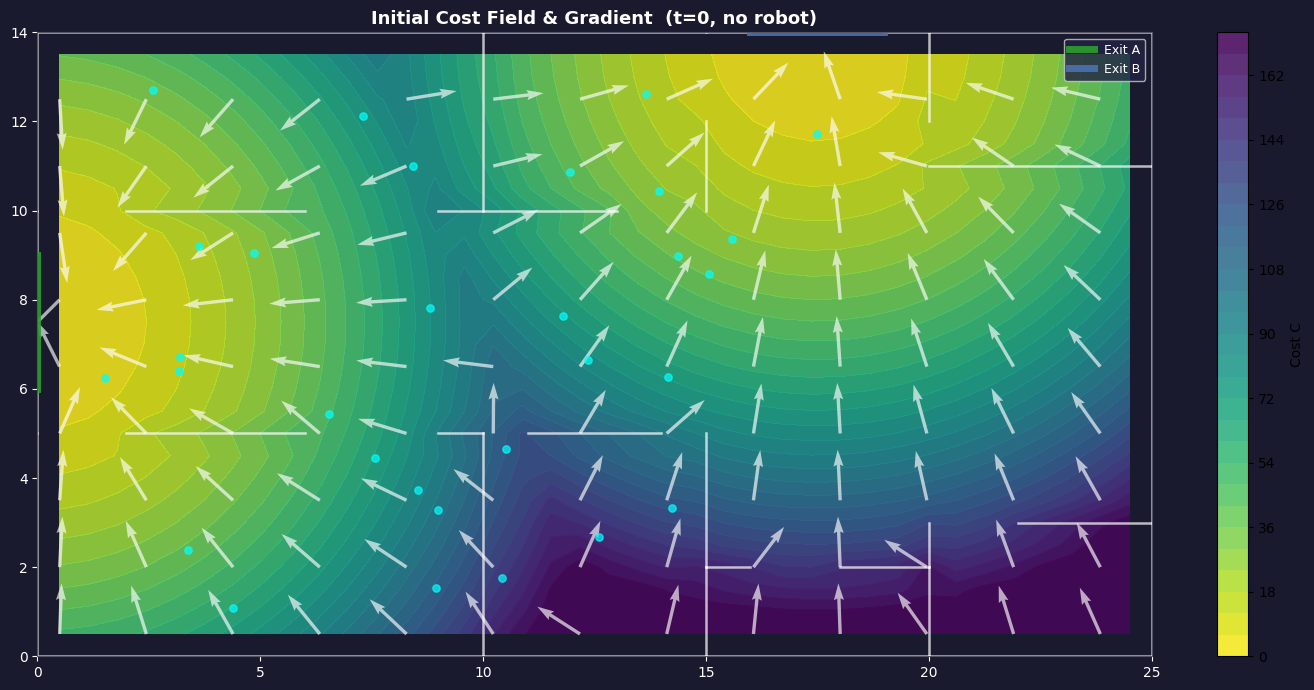

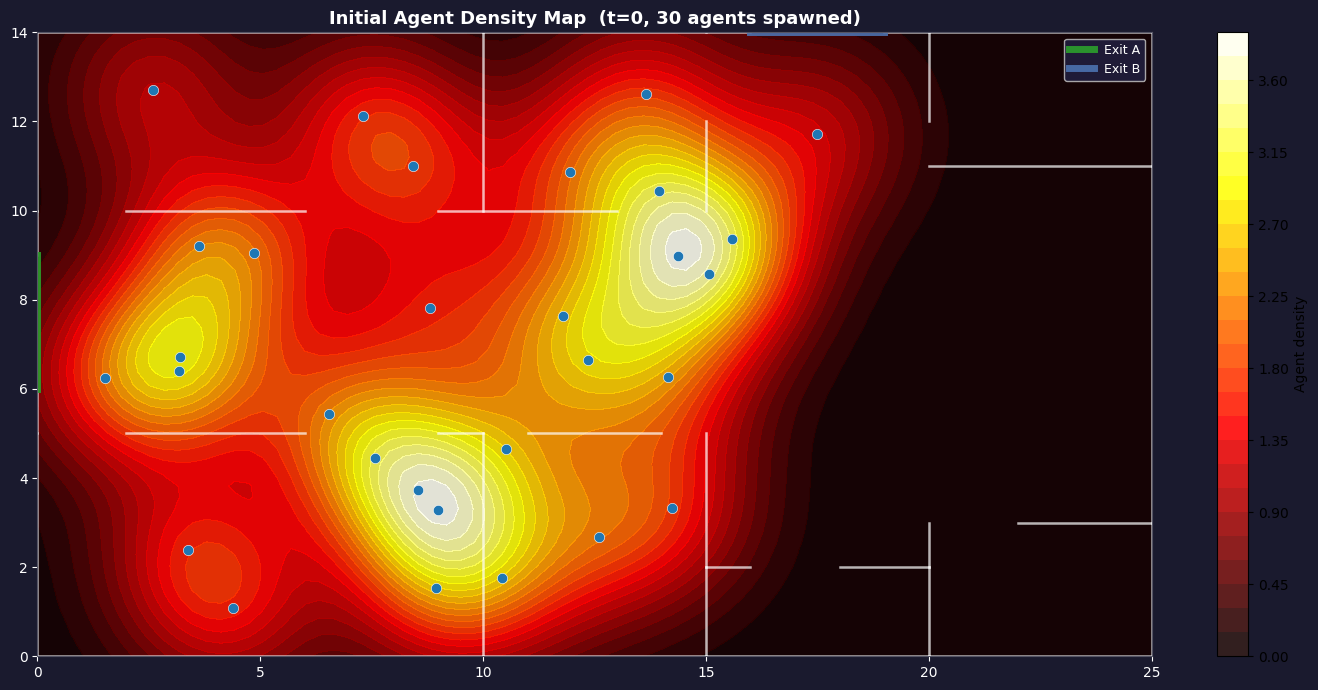

In [10]:
# Pre-simulation static visualisations
# Run AFTER all setup cells but BEFORE cell_main.
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as _plt
import numpy as _np

pos0, vel0, esc0, _ = init_sim()

# ── 1. Gradient Map ───────────────────────────────────────────────────
# print('Building initial gradient map...')
xs_g = _np.linspace(0.5,24.5,38); ys_g = _np.linspace(0.5,13.5,27)
XX_g, YY_g = _np.meshgrid(xs_g, ys_g)
kw_g = dict(tau=CFG['tau'],band=CFG['band'],w_wall=CFG['w_wall'],
            r_rep=CFG['r_rep'],w_rep=0.,r_robot=CFG['r_robot'],w_robot=CFG['w_robot'])
ZZ_g = _np.array([[total_cost(_np.array([XX_g[i,j],YY_g[i,j]]),[],None,**kw_g)
                    for j in range(XX_g.shape[1])] for i in range(XX_g.shape[0])])
UU_g = _np.zeros_like(XX_g); VV_g = _np.zeros_like(YY_g)
for i in range(XX_g.shape[0]):
    for j in range(XX_g.shape[1]):
        g = gradient_fd(_np.array([XX_g[i,j],YY_g[i,j]]),[],None,**kw_g)
        nm = _np.linalg.norm(g)
        if nm>1e-6: UU_g[i,j],VV_g[i,j]=-g[0]/nm,-g[1]/nm
fig_g,ax_g = _plt.subplots(figsize=(14,7))
fig_g.patch.set_facecolor('#1a1a2e'); ax_g.set_facecolor('#1a1a2e')
vmax_g = _np.percentile(ZZ_g,95)
cf_g = ax_g.contourf(XX_g,YY_g,_np.clip(ZZ_g,0,vmax_g),levels=30,cmap='viridis_r',alpha=0.88)
_plt.colorbar(cf_g,ax=ax_g,label='Cost C',fraction=0.025)
ax_g.quiver(XX_g[::3,::3],YY_g[::3,::3],UU_g[::3,::3],VV_g[::3,::3],
            color='white',alpha=0.65,scale=22,width=0.003)
for (x1,y1),(x2,y2) in WALL_SEGS:
    ax_g.plot([x1,x2],[y1,y2],'w-',lw=1.8,alpha=0.70)
ax_g.plot([0,0],[6,9],'-',color='#2ca02c',lw=5,alpha=0.9,label='Exit A')
ax_g.plot([16,19],[14,14],'-',color='#4c72b0',lw=5,alpha=0.9,label='Exit B')
for p in pos0: ax_g.scatter(p[0],p[1],s=28,c='cyan',alpha=0.70,zorder=5)
ax_g.set_xlim(0,25); ax_g.set_ylim(0,14); ax_g.set_aspect('equal')
ax_g.set_title('Initial Cost Field & Gradient  (t=0, no robot)',
               color='white',fontweight='bold',fontsize=13)
ax_g.legend(fontsize=9,facecolor='#222244',labelcolor='white')
ax_g.tick_params(colors='white')
for sp in ax_g.spines.values(): sp.set_edgecolor('#555566')
_plt.tight_layout()
# _plt.savefig('pre_gradient_map.png',dpi=130,bbox_inches='tight',facecolor=fig_g.get_facecolor())
_plt.show(); #print('Saved: pre_gradient_map.png')

# ── 2. Density Map ────────────────────────────────────────────────────
# print('Building initial density map...')
xs_d = _np.linspace(0,25,80); ys_d = _np.linspace(0,14,56)
XX_d, YY_d = _np.meshgrid(xs_d,ys_d); sigma_d = 1.5
ZZ_d = sum(_np.exp(-((XX_d-p[0])**2+(YY_d-p[1])**2)/(2*sigma_d**2)) for p in pos0)
fig_d,ax_d = _plt.subplots(figsize=(14,7))
fig_d.patch.set_facecolor('#1a1a2e'); ax_d.set_facecolor('#1a1a2e')
cf_d = ax_d.contourf(XX_d,YY_d,ZZ_d,levels=28,cmap='hot',alpha=0.88)
_plt.colorbar(cf_d,ax=ax_d,label='Agent density',fraction=0.025)
for (x1,y1),(x2,y2) in WALL_SEGS:
    ax_d.plot([x1,x2],[y1,y2],'w-',lw=1.8,alpha=0.70)
ax_d.plot([0,0],[6,9],'-',color='#2ca02c',lw=5,alpha=0.9,label='Exit A')
ax_d.plot([16,19],[14,14],'-',color='#4c72b0',lw=5,alpha=0.9,label='Exit B')
for p in pos0: ax_d.scatter(p[0],p[1],s=55,c='#1f77b4',edgecolors='white',lw=0.4,zorder=5)
ax_d.set_xlim(0,25); ax_d.set_ylim(0,14); ax_d.set_aspect('equal')
ax_d.set_title('Initial Agent Density Map  (t=0, 30 agents spawned)',
               color='white',fontweight='bold',fontsize=13)
ax_d.legend(fontsize=9,facecolor='#222244',labelcolor='white')
ax_d.tick_params(colors='white')
for sp in ax_d.spines.values(): sp.set_edgecolor('#555566')
_plt.tight_layout()
# _plt.savefig('pre_density_map.png',dpi=130,bbox_inches='tight',facecolor=fig_d.get_facecolor())
_plt.show(); 


### simulation

In [11]:
# ── Simulation state ──────────────────────────────────────────────────────────
pos, vel, esc, rng_sim = init_sim()
tracker = ClusterTracker()
ST = dict(
    step=0, robot_on=True,
    ee_3d=ARM.ee_world().copy(),
    centers=[], predicted=None, stuck=[], target_idx=-1,
    agent_acts=[], clust_acts=[], ee_acts=[], arm_acts=[],
    grad_acts=[], dens_act=None,
)

# ── Build scene ───────────────────────────────────────────────────────────────
static_scene = build_static_scene()
axes3d = Axes(xrange=(-5,26), yrange=(-6,15), zrange=(0,BASE_H*4+2),
              xtitle='x', ytitle='y', ztitle='z', axes_linewidth=1.5)
status_txt = Text2D('', pos='top-right', s=0.80, bg='k', c='white', alpha=0.72)

# offscreen=True  → renders to memory, no window popup, required for add_frame()
plt3d = Plotter(title='Robot Arm Simulation',
                size=(1440,900), bg='#1a1a2e', bg2='#16213e',
                interactive=False, offscreen=True)
plt3d.add(*static_scene, axes3d, status_txt)

GRAD_REFRESH = 10
DENS_REFRESH = 5

def _rm(*lists):
    for lst in lists:
        for a in lst: plt3d.remove(a)
        lst.clear()

def _refresh_arm():
    _rm(ST['arm_acts'])
    nm = ARM.update_pose()
    for m in nm: m.alpha(0.92)
    plt3d.add(*nm); ST['arm_acts'] = list(nm)

def _build_grad():
    _rm(ST['grad_acts'])
    gm, ga = make_gradient_map(ST['ee_3d'], res=26)
    plt3d.add(gm, *ga); ST['grad_acts'] = [gm] + ga

def _build_dens():
    if ST['dens_act'] is not None: plt3d.remove(ST['dens_act'])
    dm = make_density_map(pos, esc)
    plt3d.add(dm); ST['dens_act'] = dm

def _refresh_dynamic():
    _rm(ST['agent_acts'], ST['clust_acts'], ST['ee_acts'])
    aa = make_agent_actors(pos, vel, esc, ST['stuck'], ST['target_idx'])
    plt3d.add(*aa); ST['agent_acts'] = aa
    ca = make_cluster_actors(ST['centers'], ST['predicted'])
    plt3d.add(*ca); ST['clust_acts'] = ca
    ea = make_ee_actors(ST['ee_3d'])
    plt3d.add(*ea); ST['ee_acts'] = ea
    n_esc = sum(esc); n_act = sum(not e for e in esc); ee = ST['ee_3d']
    ee_s  = f'({ee[0]:.1f},{ee[1]:.1f},z={ee[2]:.1f})'
    ph_s  = '  '.join(f'phi{k+1}={v:.0f}d' for k,v in enumerate(ARM.phi))
    tgt_s = f'Agent {ST["target_idx"]}' if ST['target_idx'] >= 0 else '---'
    swp_s = f'{min(ARM._dwell_count,ARM.dwell_steps)}/{ARM.dwell_steps}' if ST['target_idx'] >= 0 else '-'
    status_txt.text(
        f' Step:    {ST["step"]}\n'
        f' Escaped: {n_esc}/{len(pos)}\n'
        f' Active:  {n_act}\n'
        f' Stuck:   {len(ST["stuck"])}\n'
        f' Target:  {tgt_s}  sweep {swp_s}\n'
        f' EE 3D:   {ee_s}\n'
        f' Robot:   ON\n'
        f' {ph_s}'
    )

# ── Initial scene ─────────────────────────────────────────────────────────────
_refresh_arm(); _refresh_dynamic()
print('Building initial gradient overlay...'); _build_grad()
print('Building initial density overlay...');  _build_dens()

# Show initial frame (needed to initialise the offscreen renderer)
plt3d.show(camera={'pos':(12,-30,35), 'focal_point':(12,6,2), 'viewup':(0,0,1)},
           interactive=False)

# ── vedo Video recorder ───────────────────────────────────────────────────────
from vedo import Video
import subprocess, shutil

if shutil.which('ffmpeg') is None:
    print('Installing ffmpeg...')
    subprocess.run(['apt-get','install','-y','-q','ffmpeg'], check=False)

OUT_MP4  = 'simulation_robot_arm.mp4'
MAX_STEPS = 800    # safety cap — stops early when all escaped

video = Video(OUT_MP4, fps=10, backend='ffmpeg')

print(f'Recording 3-D vedo simulation → {OUT_MP4}')
print('(runs until all 30 agents escape, max', MAX_STEPS, 'steps)\n')

for step in range(MAX_STEPS):
    # ── Simulation tick ───────────────────────────────────────────────────
    newpos, newvel, newesc = step_sim(pos, vel, esc, rng_sim, ST['ee_3d'])
    pos[:] = newpos; vel[:] = newvel
    for i in range(len(esc)): esc[i] = newesc[i]

    centers, labels, stuck, primary, predicted = tracker.update(pos, vel, esc)
    ST['centers'] = centers; ST['predicted'] = predicted; ST['stuck'] = stuck

    tgt_idx = ARM.step(pos, vel, esc)
    ST['target_idx'] = tgt_idx; ST['ee_3d'] = ARM.ee_world().copy()

    # ── Refresh overlays on schedule ──────────────────────────────────────
    if step % GRAD_REFRESH == 0: _build_grad()
    if step % DENS_REFRESH == 0: _build_dens()
    _refresh_arm(); _refresh_dynamic()

    ST['step'] += 1

    # ── Render & capture frame ────────────────────────────────────────────
    plt3d.render()
    video.add_frame()

    if step % 1 == 0:
        print(f'  Step {step:4d}  escaped={sum(esc)}/{len(pos)}  '
              f'stuck={len(stuck)}  target={tgt_idx}')

    if all(esc):
        print(f'\n  All {len(pos)} agents escaped at step {step}!')
        # Hold the final frame for 2 seconds
        video.pause(2)
        break

video.close()
plt3d.close()

import os
size_mb = os.path.getsize(OUT_MP4) / 1e6
print(f'\nSaved: {OUT_MP4}  ({size_mb:.1f} MB)')


Building initial gradient overlay...
Building initial density overlay...
📽  Video file simulation_robot_arm.mp4 is open... Recording 3-D vedo simulation → simulation_robot_arm.mp4
(runs until all 30 agents escape, max 800 steps)

  Step    0  escaped=0/30  stuck=0  target=-1
  Step    1  escaped=0/30  stuck=0  target=-1
  Step    2  escaped=0/30  stuck=0  target=-1
  Step    3  escaped=0/30  stuck=0  target=-1
  Step    4  escaped=0/30  stuck=0  target=-1
  Step    5  escaped=2/30  stuck=0  target=-1
  Step    6  escaped=2/30  stuck=0  target=-1
  Step    7  escaped=2/30  stuck=0  target=-1
  Step    8  escaped=2/30  stuck=0  target=-1
  Step    9  escaped=2/30  stuck=1  target=4
  Step   10  escaped=2/30  stuck=0  target=-1
  Step   11  escaped=2/30  stuck=1  target=2
  Step   12  escaped=3/30  stuck=3  target=23
  Step   13  escaped=4/30  stuck=2  target=2
  Step   14  escaped=4/30  stuck=0  target=-1
  Step   15  escaped=5/30  stuck=0  target=-1
  Step   16  escaped=5/30  stuck=2  t



### Q1 — How does the robot arm know where the stuck agents are?

The simulation uses **Mean-Shift clustering** (bandwidth 1.5 floor units) applied to agents that satisfy:
- Not escaped  
- Within 4.5 floor units of any exit ('exit_radius')  
- Speed < 0.10 ('stuck_speed')

The largest cluster's centroid is tracked over a rolling 10-frame window. A **linear velocity prediction** with horizon $h = 4$ frames gives the predicted future cluster position, which the arm uses as its general operating region.

For individual targeting, the robot sorts stuck agents by 'corner_score(i) = min_j\{d(p_i, \text{wall}_j)\}' and picks the most wall-cornered one first — the agent least likely to self-escape without help.

---

### Q2 — How does the robot physically move the agent?

The robot does **not** directly control agent positions. Instead:

1. IK positions the EE tip at $\mathbf{e} = (e_x, e_y, 0.22)$ — 0.3 floor units behind the agent in the direction opposite the target waypoint.
2. This adds $C_{\text{robot}}^{\text{3D}}$ to the cost field.
3. $\nabla C_{\text{robot}}^{\text{3D}}$ at the agent's position points **away from the EE** = toward the waypoint.
4. The agent's gradient-descent update now incorporates this extra force: $|\nabla C| \approx 21.3$ vs 8.1 without robot — **2.6× amplification**.
5. The agent follows the modified gradient into the corridor, then self-navigates to the exit via $C_{\text{goal}}$.

---

### Q3 — Why door-aware waypoints instead of exit-direct?

An agent in the south-west room (x < 10, y < 5) is bounded by a solid wall at y = 5 (segments (2,5)–(6,5) and (9,5)–(10,5)). The nearest exit is Exit A at (0, 7.5), which is directly north — but the wall blocks that path.

Pushing toward the exit places the EE at roughly (1.1, 4.5), which pushes the agent northwest — directly into the wall. With descent direction $(-0.41, -0.91)$, the agent hits y = 5 and stops.

Pushing toward the door gap at (7.5, 5.0) instead places the EE at (0.7, 4.8), producing descent direction $(+0.94, -0.34)$ — **eastward toward the gap**. Once through the 3-unit gap (x = 6..9 at y = 5), the agent enters the west corridor where $C_{\text{goal}}$ naturally pulls it west to Exit A.

---

### Q4 — What is the role of IK in this simulation?

IK serves as the **bridge between the planning layer and the physical arm**:

- **Planning** decides WHERE to position the EE (door-aware waypoint → sweep offset)
- **IK** decides WHAT joint angles $\boldsymbol{\phi} = (\phi_1,\phi_2,\phi_3,\phi_4)$ achieve that EE position

Without IK, we could not express "place the tip at (5.2, 4.8, 0.22)" in terms of arm motor commands. The Jacobian pseudo-inverse translates Cartesian error into joint-space corrections. The multi-init strategy ensures the arm always reaches floor level, which is geometrically challenging for some positions (arm must fold over itself).

---

### Q5 — Key observations from the simulation

| Observation | Explanation |
|-------------|-------------|
| **Arm hovers overhead initially** | IK first homes the arm; EE at z≈15 has zero cost influence |
| **Cost map changes only when arm descends** | 3D distance formula: no ghost forces from overhead positions |
| **Gradient arrows deflect near EE** | $C_{\text{robot}}^{\text{3D}}$ hill deforms the local field — visible in grad map |
| **Robot helps one agent at a time** | 'dwell_steps=100' ensures sustained push before switching |
| **Agents sometimes cluster at doorways** | Social repulsion ($C_{\text{rep}}$) limits how many can pass simultaneously |
| **Robot returns home when no stuck agents** | Slow tracking to neutral pose — arm resets between rescue missions |
| **Door-pushed agents self-navigate after** | Once in corridor, $C_{\text{goal}}$ is unobstructed — no further robot help needed |
